## imports

In [109]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [110]:

from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2
from stable_baselines3 import PPO
from irc_gym.irc.model import FuncBeliefModel
import multiprocess
from ult import *

# agent and task

In [111]:
modelnamefull='14thcheckpoint'

modelname = 'varyrewardperoid2'
# training hyper params
epoch_size = 33333
n_epoch = 22
n_seed = 1
modeli = 0


no_episodes = 9999
epochtouse = 8

attcost = -1.6
facost = -50
p1p2 = np.array([.5, .7])
seed = 0
np.random.seed(seed)

vmin, vmax = 10, 10000
food_reward_list = np.linspace(vmin, vmax, 5)
env_param = [0, None, attcost, .25, facost, 0, 0]

thismodel = f'seed_{seed}_{modelname}_{modeli}'

task = AFR2(spec={'agent': {'lick_cost': env_param[0],
                            'food_reward': env_param[1],
                            'attention_cost_coeff': env_param[2],
                            'attention_cost_temp': env_param[3],
                            'penalty_cost': env_param[4],
                            'iti_cost': env_param[5],
                            'time_in_game_reward': env_param[6]}})
task.food_reward_list = food_reward_list
taskbelief = FuncBeliefModel(env=task, rng=1)
task.obs_certainity_possible = p1p2
model = PPO.load(f'ycstore/{thismodel}_epoch_{epochtouse}')

model = PPO.load(f'ycstore/{modelnamefull}')


# plot

color choice, gradient

axis, 
pick a better model



In [112]:
# collect trial data
def eval_wrapper(a):
    episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                              num_steps=100000, deterministic=True)
    return episode

with multiprocess.Pool(processes=6) as pool:
    all_episode_data = pool.map(eval_wrapper, range(no_episodes))

In [113]:
# process trial data
def process_one_episode_wrapper(episode):
    return process_one_episode(episode, task)
with multiprocess.Pool(processes=6) as pool:
    results = pool.map(process_one_episode_wrapper, all_episode_data)

# process the mp results
hit_count_list = [[0] for _ in range(len(food_reward_list))]
miss_count_list = [[0] for _ in range(len(food_reward_list))]
false_alarm_list = [[0] for _ in range(len(food_reward_list))]

noise_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
signal_time_before_lick_list = [[0] for _ in range(len(food_reward_list))]
total_noise_time_list = [[0] for _ in range(len(food_reward_list))]
total_signal_time_list = [[0] for _ in range(len(food_reward_list))]

# dist naming space: list of list of num. big list of each reward cond. small list of each trial's summary stats, which is a single number.
total_reward_dist= [[] for _ in range(len(food_reward_list))]
rt_hit_dist=[[] for _ in range(len(food_reward_list))]
rt_fa_dist=[[] for _ in range(len(food_reward_list))]
total_att_time_dist = [[] for _ in range(len(food_reward_list))]
for res in results:
    (food_reward_idx,
     hit_count,
     miss_count,
     false_alarm_count,

     noise_time_before_lick,
     signal_time_before_lick,
     total_noise_time,
     total_signal_time,

     total_reward,

     attention_time_points_across_episodes,
     episode_length_across_episodes,
     hit_reaction_time_across_episodes,
     fa_reaction_time_across_episodes
     ) = res

    hit_count_list[food_reward_idx][0] += (hit_count)
    miss_count_list[food_reward_idx][0] += (miss_count)
    false_alarm_list[food_reward_idx][0] += (false_alarm_count)

    noise_time_before_lick_list[food_reward_idx][0] += (noise_time_before_lick)
    signal_time_before_lick_list[food_reward_idx][0] += (
        signal_time_before_lick)
    total_noise_time_list[food_reward_idx][0] += (total_noise_time)
    total_signal_time_list[food_reward_idx][0] += (total_signal_time)

    total_reward_dist[food_reward_idx].append(total_reward)
    rt_hit_dist[food_reward_idx].append(signal_time_before_lick)
    rt_fa_dist[food_reward_idx].append(noise_time_before_lick)
    total_att_time_dist[food_reward_idx].append(len(attention_time_points_across_episodes[0]))

# plot

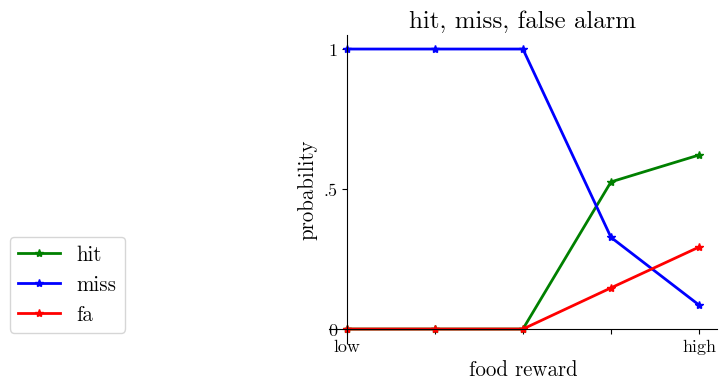

In [114]:
# 3 curve
hit_count_list, miss_count_list, false_alarm_list = np.array(
    hit_count_list), np.array(miss_count_list), np.array(false_alarm_list)
hit_prob = [hit_count_list[i]/(hit_count_list[i]+miss_count_list[i] +
                                false_alarm_list[i]) for i in range(len(hit_count_list))]
miss_prob = [miss_count_list[i]/(hit_count_list[i]+miss_count_list[i] +
                                    false_alarm_list[i]) for i in range(len(hit_count_list))]
fa_prob = [false_alarm_list[i]/(hit_count_list[i]+miss_count_list[i] +
                                false_alarm_list[i]) for i in range(len(hit_count_list))]

xs=np.arange(len(food_reward_list))
fig, ax=plt.subplots(1,1, figsize=(5,4))

ax.plot(xs, hit_prob, '-*g', label='hit')
ax.plot(xs, miss_prob, '-*b', label='miss')
ax.plot(xs, fa_prob, '-*r', label='fa')
quickleg(ax, bbox_to_anchor=(-0.5,0))
ax.set_xlabel('food reward')
ax.set_ylabel('probability')
# ax.set_xticks(xs, [f'{a:.0f}' for a in food_reward_list]) # actual values
ax.set_xticks([xs[i] for i in [0,-1]], ['low', 'high']) # low high
ax.set_xticks(xs)
ax.set_yticks([0,0.5,1], ['0', '.5','1'])
ax.set_xticks(xs)
centerax(ax)
ax.set_title('hit, miss, false alarm')
plt.show()

# quicksave('hit and fa',modelname, fig=f)

webf NOT subset; don't know how to subset; dropped


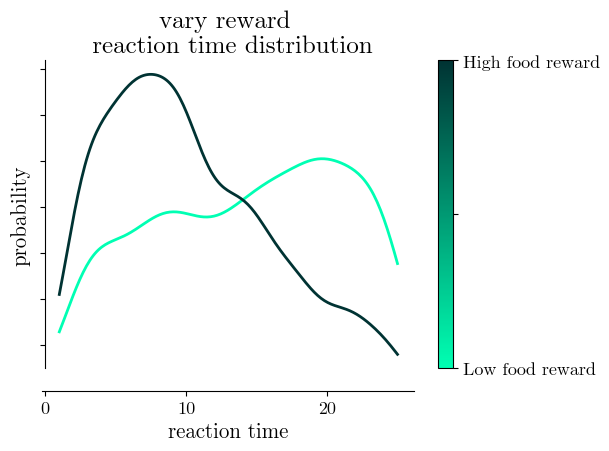

In [115]:
# reaction time

start_rgb = (0.0, 1, 0.7)
end_rgb = (0.0, 0.2, 0.2)
cmap = LinearSegmentedColormap.from_list('custom_cmap', [start_rgb, end_rgb])


fig, ax = plt.subplots(1, 1, figsize=(6, 4))
data = []
for food_reward_idx, v in enumerate(rt_hit_dist):
    v = np.array(v)
    v = v[v > 1]  # ignore the 0 reaction time in the plots
    if len(v) == 0:
        continue
    data.append((food_reward_idx, v))


for i, (food_reward_idx, curve) in enumerate(data):
    sns.kdeplot(curve, label=f'reward:{food_reward_list[food_reward_idx]:.0f}', clip=(1, np.max(v)), bw_adjust=1,color=cmap(np.linspace(0, 1, len(data)))[i])

    # plt.plot(curve, color=cmap(np.linspace(0, 1, len(data)))[i])
color_bar=plt.colorbar(plt.cm.ScalarMappable(cmap=cmap),ax=ax)
ticks = [0, 0.5, 1]
tick_labels = ['Low food reward', '', 'High food reward']
color_bar.set_ticks(ticks)
color_bar.set_ticklabels(tick_labels)

ax.set_ylabel('probability')
ax.set_xlabel('reaction time')
centerax(ax)
ax.set_xticks([0, 10, 20])
ax.set_yticklabels([])
# quickleg(ax, bbox_to_anchor=(-0.5, 0))
ax.set_title('vary reward \n reaction time distribution')
quicksave('reaction time distribution v3 full', modelname)
plt.show()